# Enviroment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = 'YOUR_PATH'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/RF'

# Processed Data

In [4]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

In [5]:
FEATURES = [
    'year', 'month', 'day_of_week', 'day_of_year', 'week_of_year',
    'is_weekend', 'is_holiday', 'is_after_weekend', 'is_after_holiday',
    'tavg', 'prcp', 'wspd',
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7_mean', 'rolling_7_std', 'rolling_30_mean',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos'
]

TARGET = 'total_tonnes'

# Model Definition - Random Forest

In [6]:
def run_rf_prediction(df, dataset_name, dataset_code, dataset_number, features, test_days=90):
    """
    Train Random Forest on a single dataset and return metrics + predictions.
    Uses walk-forward prediction: for each test day, uses actual lag values
    from previous days (including already-predicted test days).
    """
    print(f"\n{'='*100}")
    print(f"Random Forest PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)

    # feature filtering
    available_features = [f for f in features if f in df.columns]
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"Note: Missing features (skipped): {missing_features}")

    # test / train split
    split_idx = len(df) - test_days
    train = df.iloc[:split_idx].copy()
    test = df.iloc[split_idx:].copy()

    print(f"Train: {len(train)} days ({train['date'].min().date()} → {train['date'].max().date()})")
    print(f"Test:  {len(test)} days ({test['date'].min().date()} → {test['date'].max().date()})")
    print(f"Features used: {len(available_features)}")

    # model fit
    X_train = train[available_features]
    y_train = train[TARGET]

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)
    print("Model trained.")

    # walk-forward prediction on test set - no negatives
    predictions = []
    test_copy = test.copy()

    for i in range(len(test_copy)):
        row = test_copy.iloc[i:i+1][available_features]
        pred = model.predict(row)[0]
        pred = max(pred, 0)
        predictions.append(pred)

        # update lag features for next predictions
        idx = test_copy.index[i]
        if i + 1 < len(test_copy):
            next_idx = test_copy.index[i + 1]
            if 'lag_1' in available_features:
                test_copy.loc[next_idx, 'lag_1'] = pred
            if 'lag_2' in available_features and i + 2 < len(test_copy):
                test_copy.loc[test_copy.index[min(i+2, len(test_copy)-1)], 'lag_2'] = pred

    y_true = test[TARGET].values
    y_pred = np.array(predictions)

    # metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    nonzero_mask = y_true > 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    else:
        mape = float('nan')

    print(f"\n--- RESULTS ---")
    print(f"MAE:  {mae:.2f} tonnes")
    print(f"RMSE: {rmse:.2f} tonnes")
    print(f"MAPE: {mape:.2f}%")


    # --- Plot 4X1: Actual vs Predicted (test period) - Random Forest ---
    fig, ax = plt.subplots(figsize=(16, 6))

    context = train.iloc[-30:]
    ax.plot(context['date'], context[TARGET], color='steelblue',
            linewidth=1, label='Training Data (last 30 days)')

    ax.plot(test['date'], y_true, color='steelblue',
            linewidth=1.5, label='Actual (Test)')

    ax.plot(test['date'], y_pred, color='red',
            linewidth=1.5, linestyle='--', label='Random Forest Forecast')

    ax.axvline(x=test['date'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

    ax.set_title(f'Random Forest Forecast vs Actual — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    ax.text(0.02, 0.95,
            f'MAE: {mae:.2f}t\nRMSE: {rmse:.2f}t\nMAPE: {mape:.1f}%',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'4{dataset_number}1_rf_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 4X2: Zoom on firts 30 days of test - Random Forest ---
    fig, ax = plt.subplots(figsize=(14, 5))

    zoom_days = min(30, test_days)
    ax.plot(test['date'].iloc[:zoom_days], y_true[:zoom_days],
            color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')

    ax.plot(test['date'].iloc[:zoom_days], y_pred[:zoom_days],
            color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='Random Forest')

    ax.set_title(f'Random Forest Forecast (First {zoom_days} Days) — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'4{dataset_number}2_rf_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 4X3: Feature importance - Random Forest ---
    fig, ax = plt.subplots(figsize=(10, 8))

    importance = pd.Series(model.feature_importances_, index=available_features)
    importance = importance.sort_values(ascending=True)
    importance.tail(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

    ax.set_title(f'Top 15 Feature Importance — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'4{dataset_number}3_rf_feature_importance_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    return {
        'dataset': dataset_name,
        'model': 'Random Forest',
        'mae': round(mae, 2),
        'rmse': round(rmse, 2),
        'mape': round(mape, 2),
        'test_days': test_days
    }

# Model Prediction - Random Forest


Random Forest PREDICTION — Boralesgamuwa UC (Sri Lanka)
Train: 2287 days (2012-01-31 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  6.01 tonnes
RMSE: 8.33 tonnes
MAPE: 41.23%


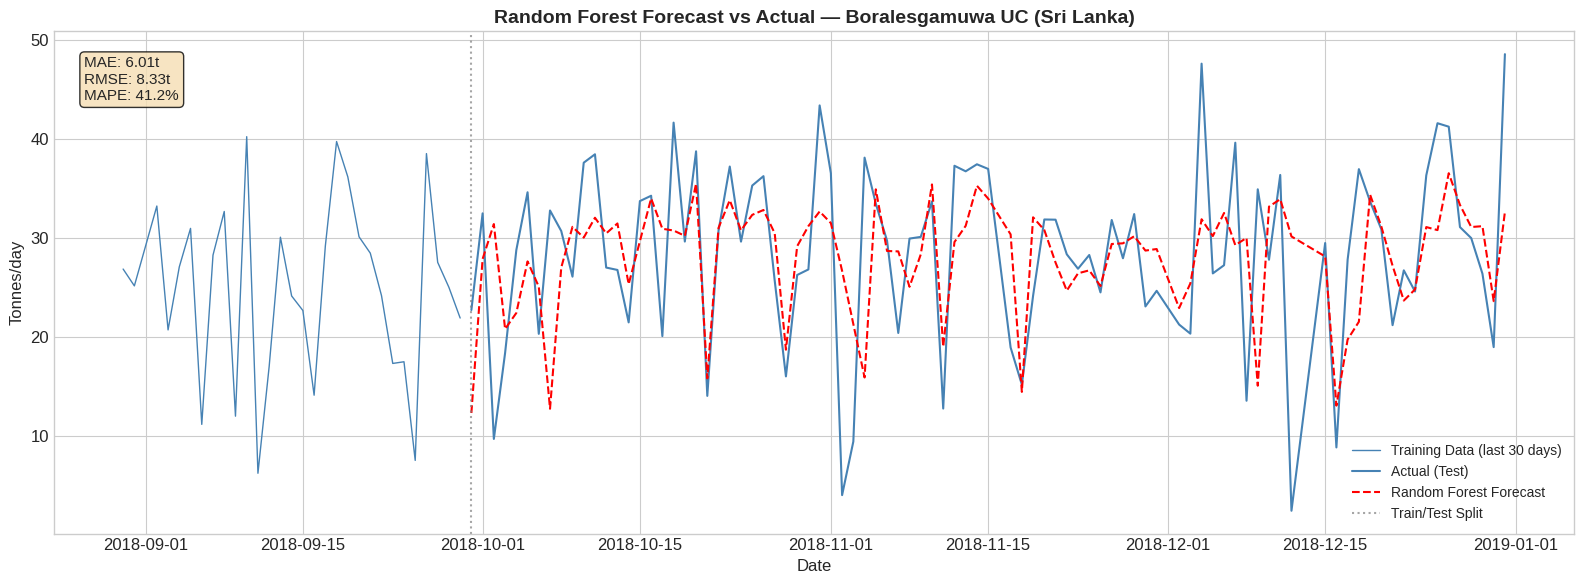

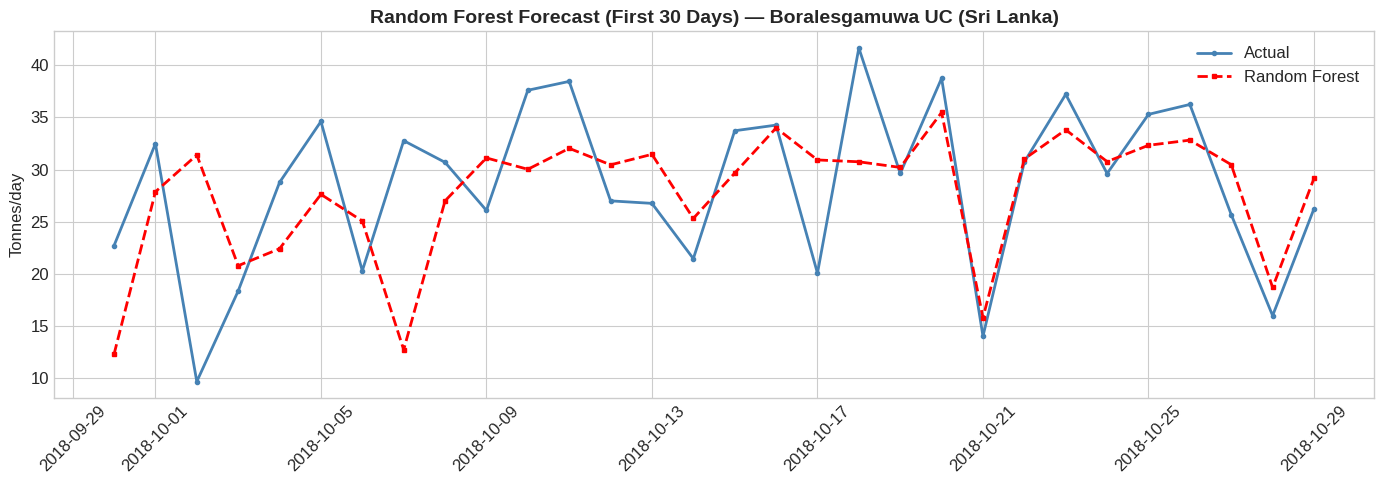

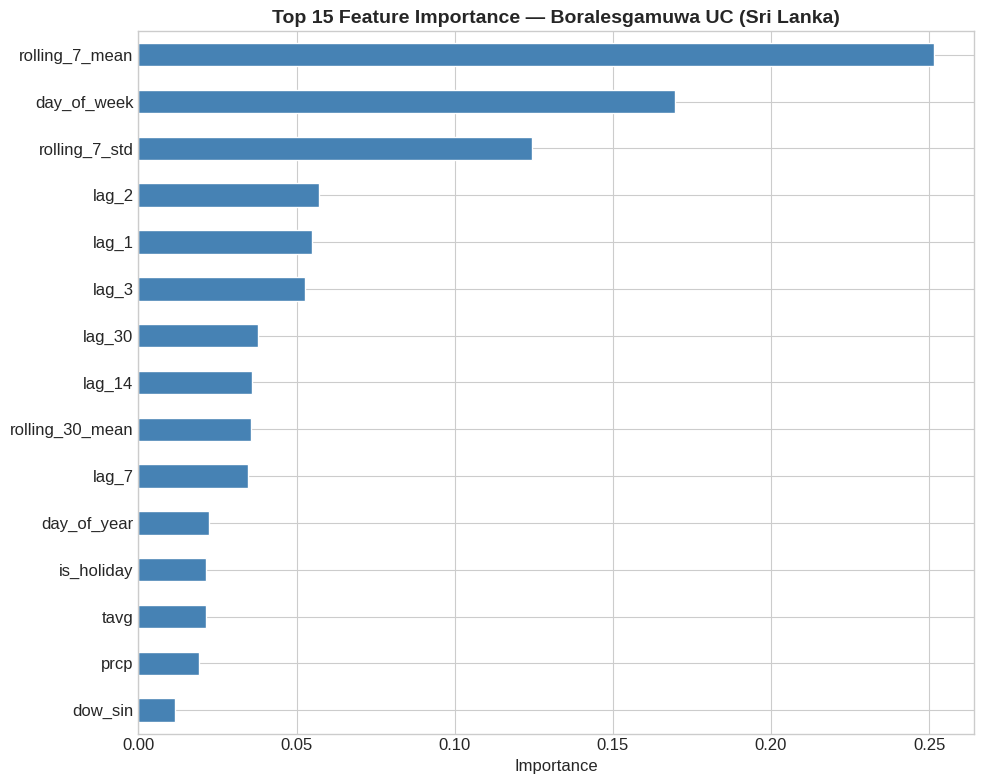


Random Forest PREDICTION — Dehiwala MC (Sri Lanka)
Train: 2003 days (2012-01-31 → 2018-09-25)
Test:  90 days (2018-09-26 → 2018-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  23.50 tonnes
RMSE: 34.46 tonnes
MAPE: 39.05%


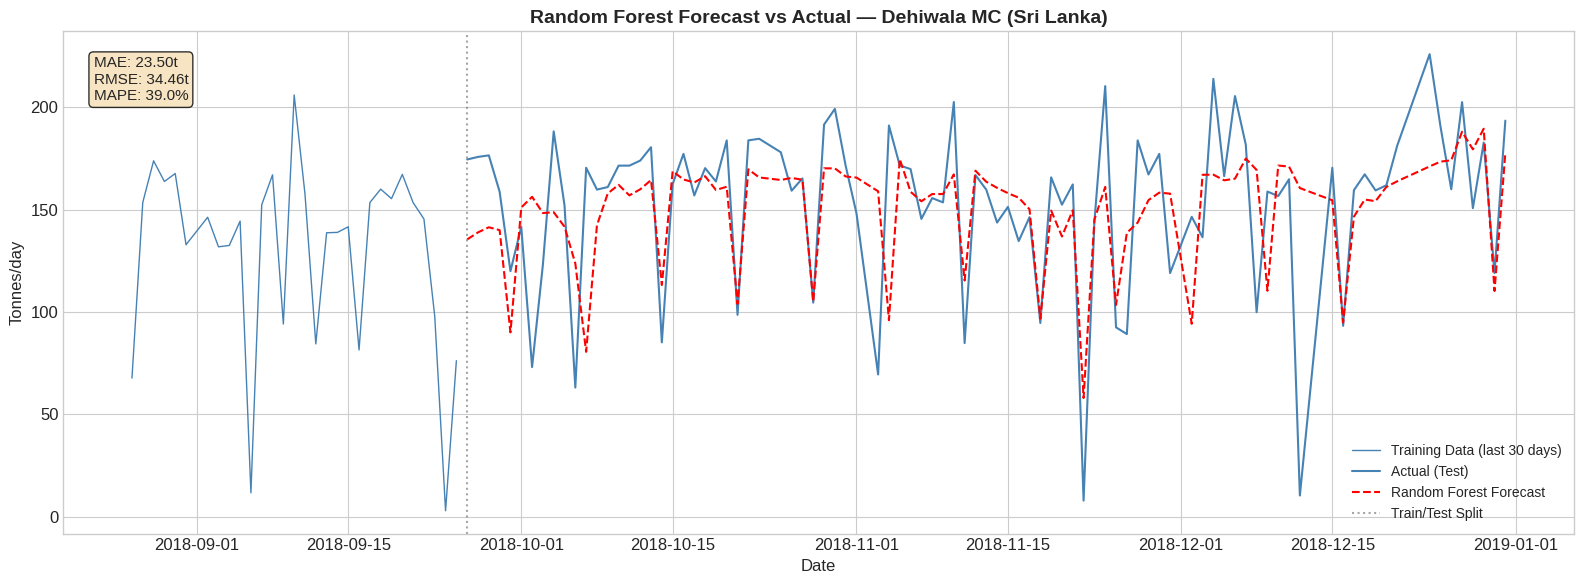

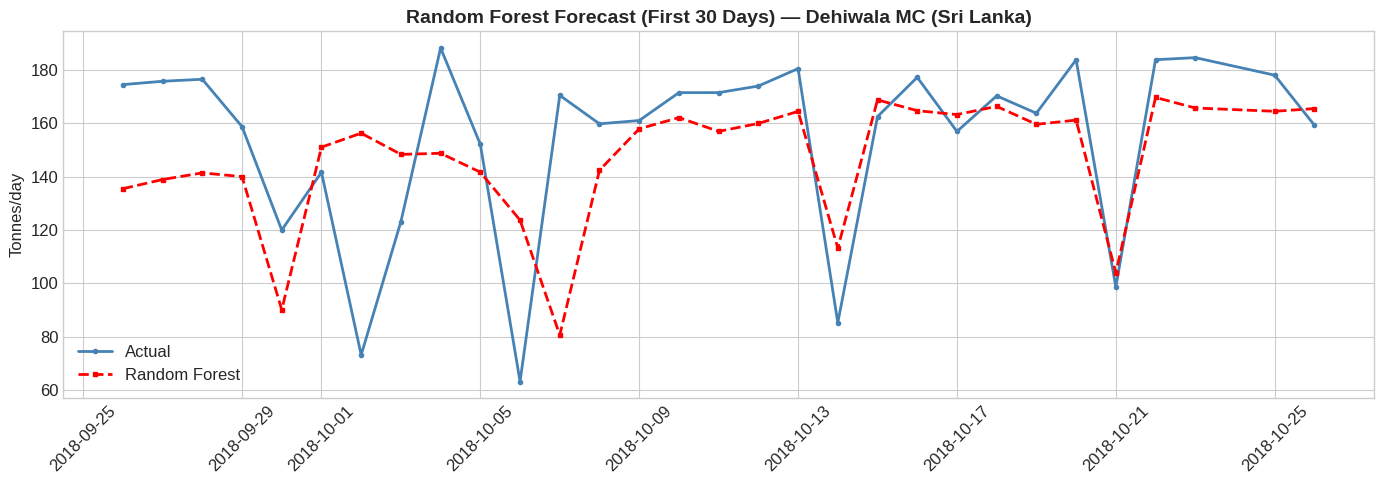

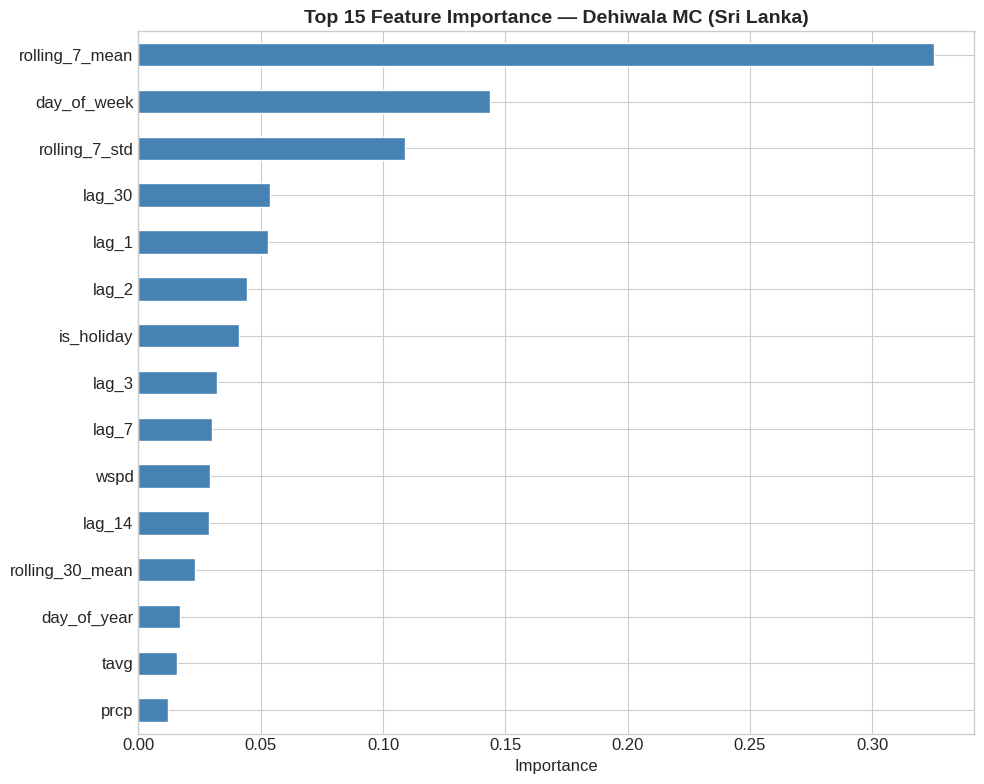


Random Forest PREDICTION — Homagama PS (Sri Lanka)
Train: 1944 days (2012-02-02 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  10.75 tonnes
RMSE: 13.60 tonnes
MAPE: 36.46%


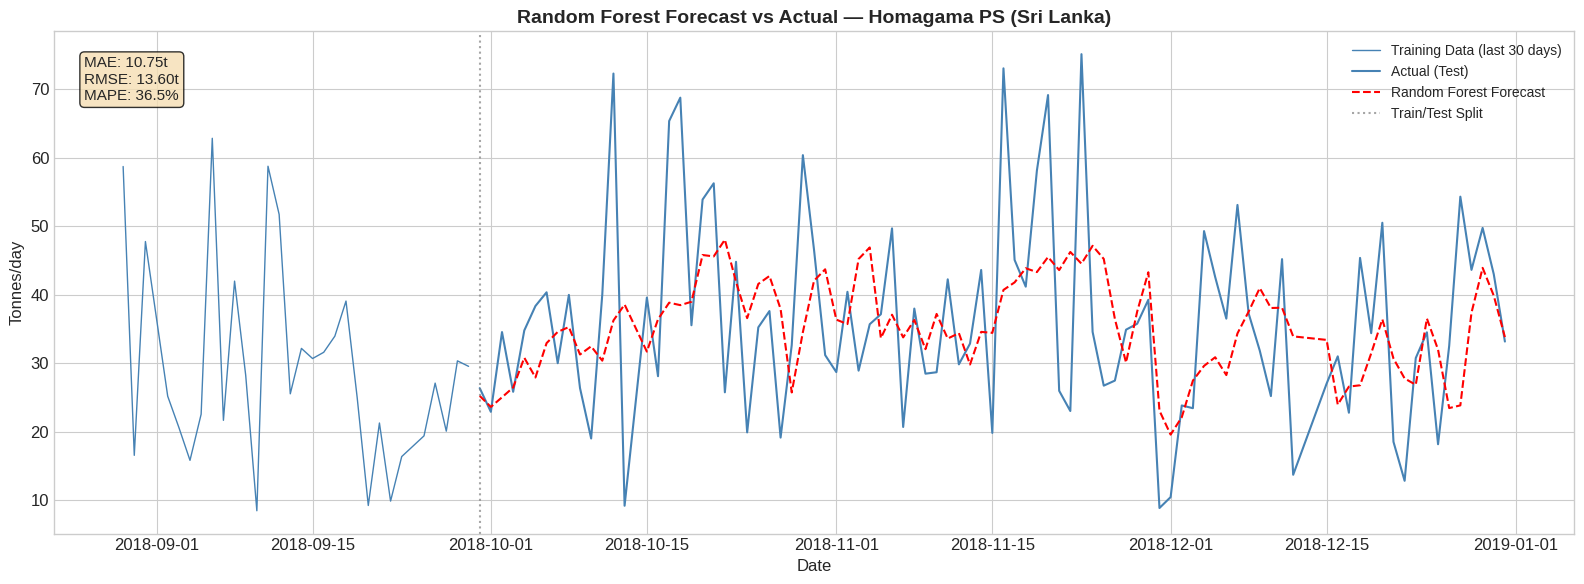

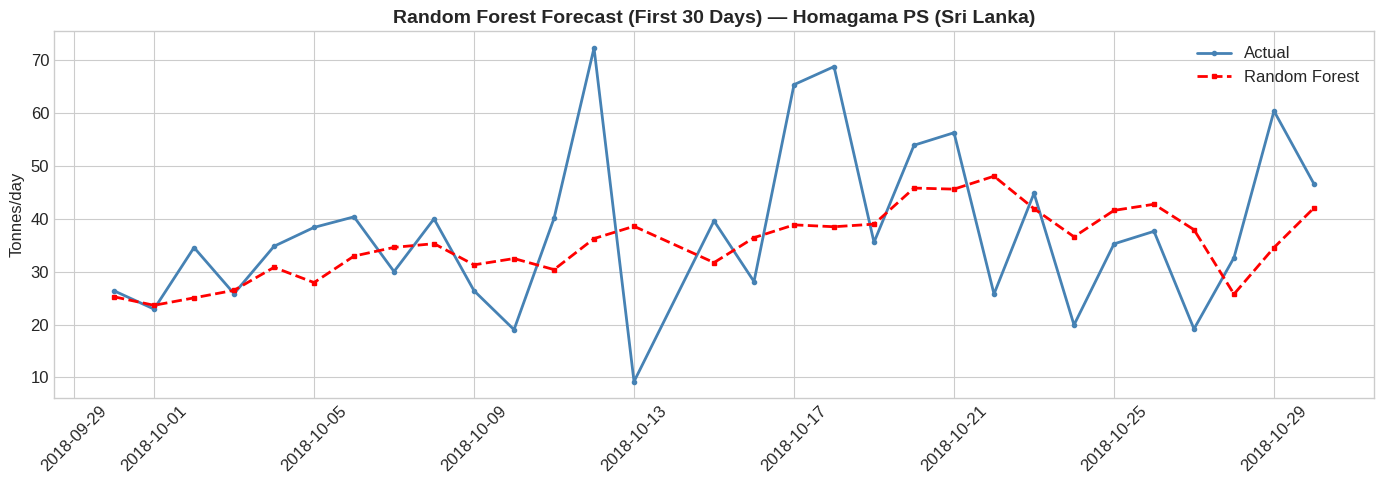

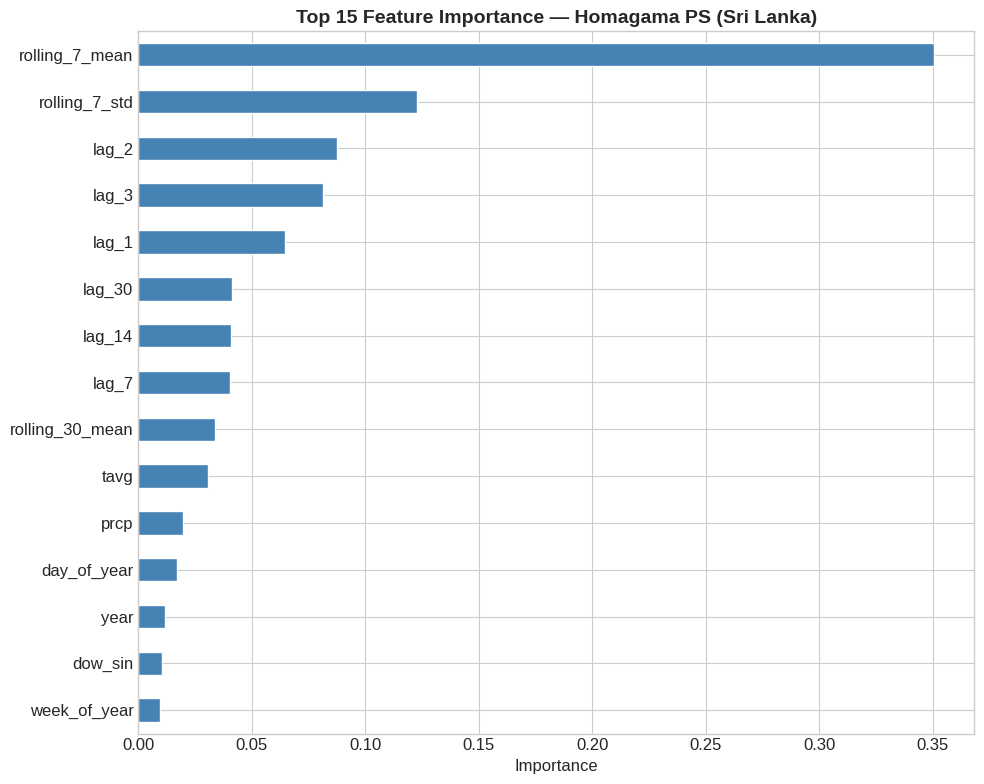


Random Forest PREDICTION — Moratuwa MC (Sri Lanka)
Train: 1176 days (2015-01-31 → 2018-09-08)
Test:  90 days (2018-09-09 → 2018-12-11)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  19.69 tonnes
RMSE: 25.72 tonnes
MAPE: 31.61%


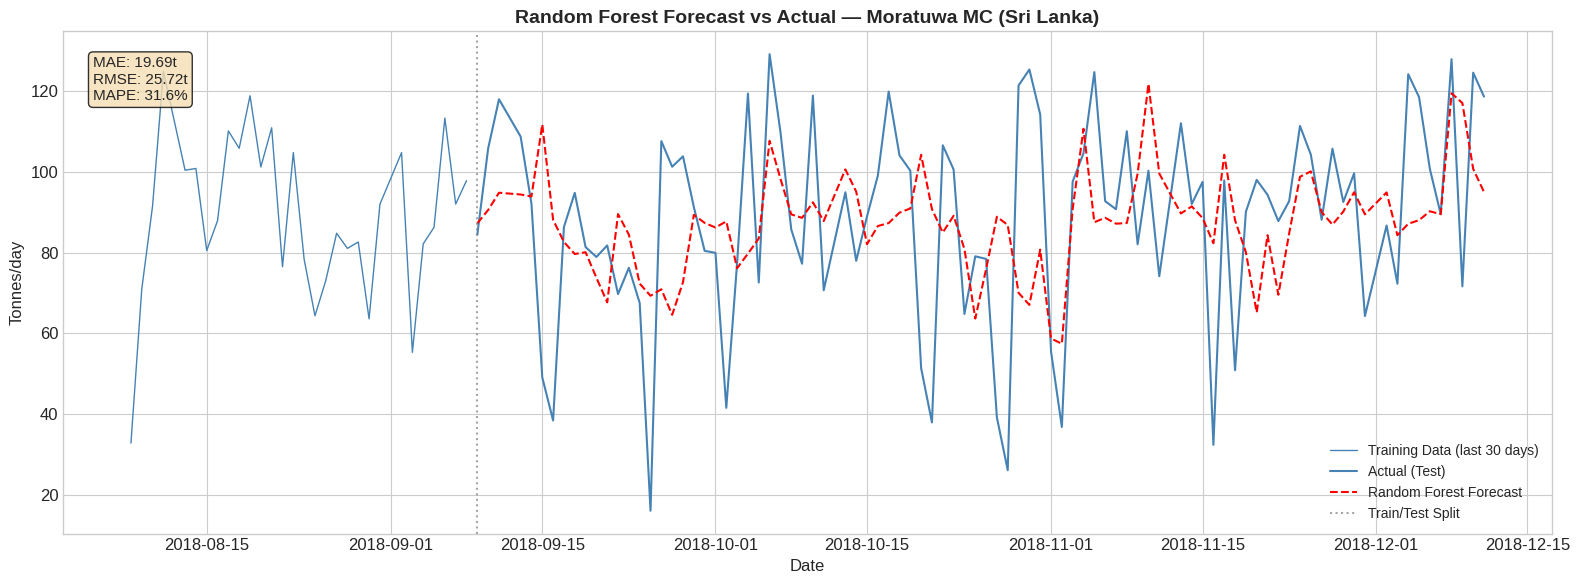

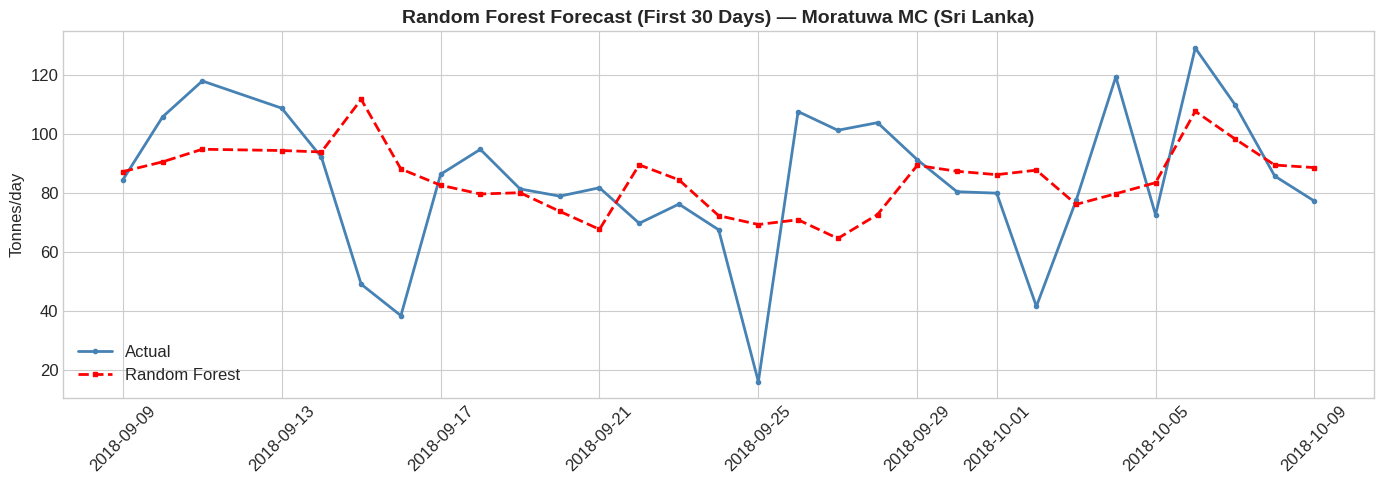

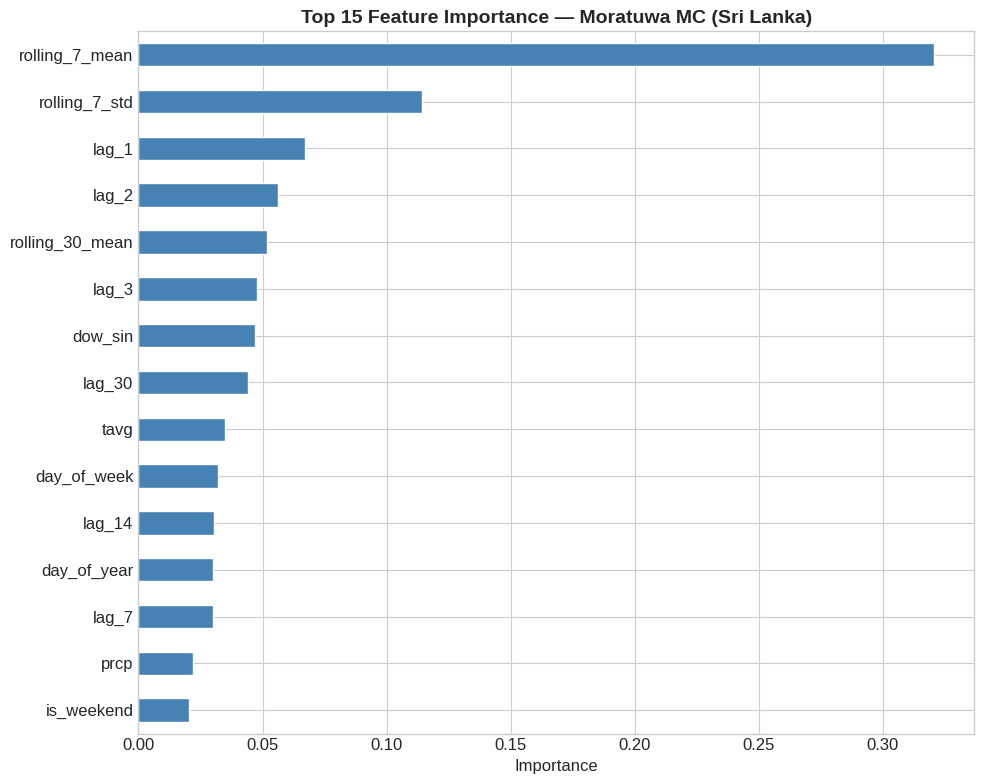


Random Forest PREDICTION — Austin TX (USA)
Train: 5208 days (2005-02-01 → 2020-09-18)
Test:  90 days (2020-09-19 → 2020-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  155.64 tonnes
RMSE: 343.90 tonnes
MAPE: 35.07%


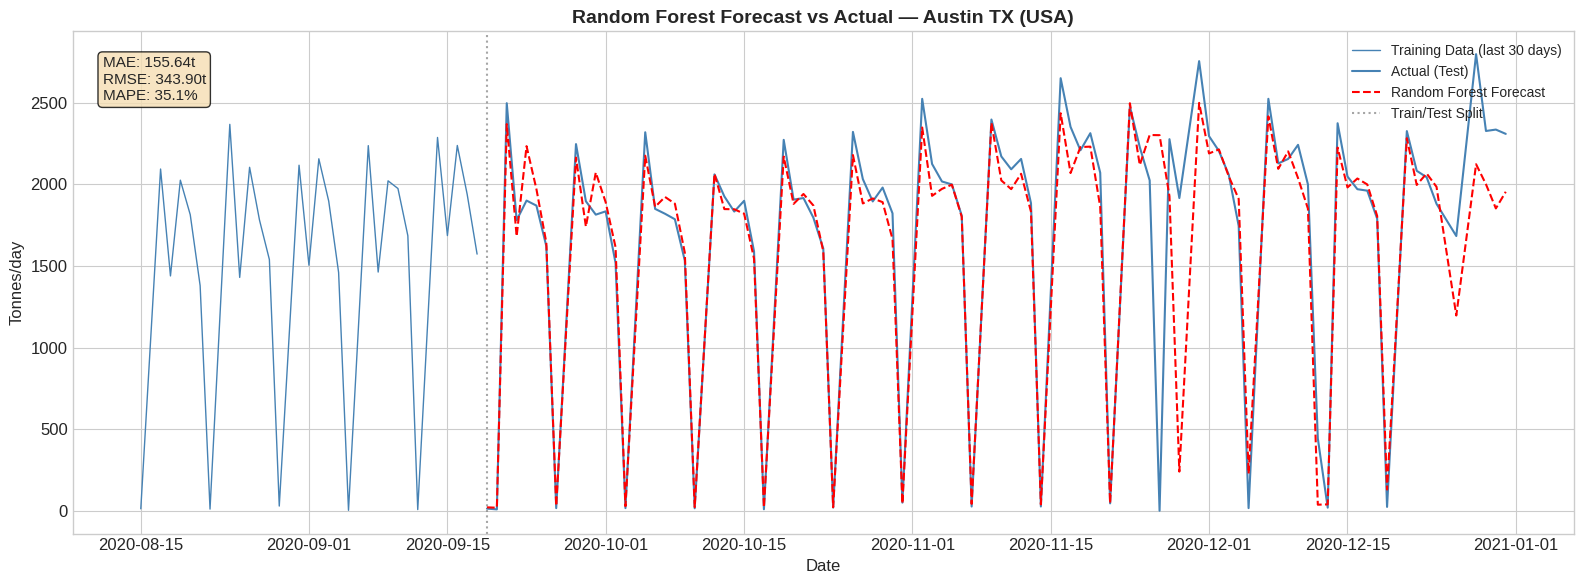

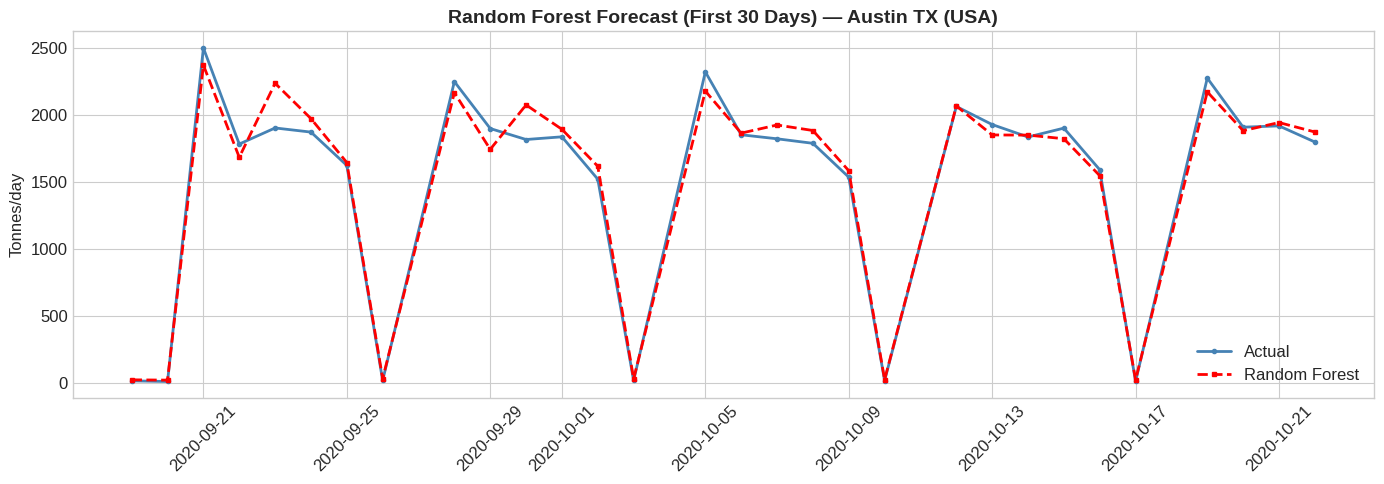

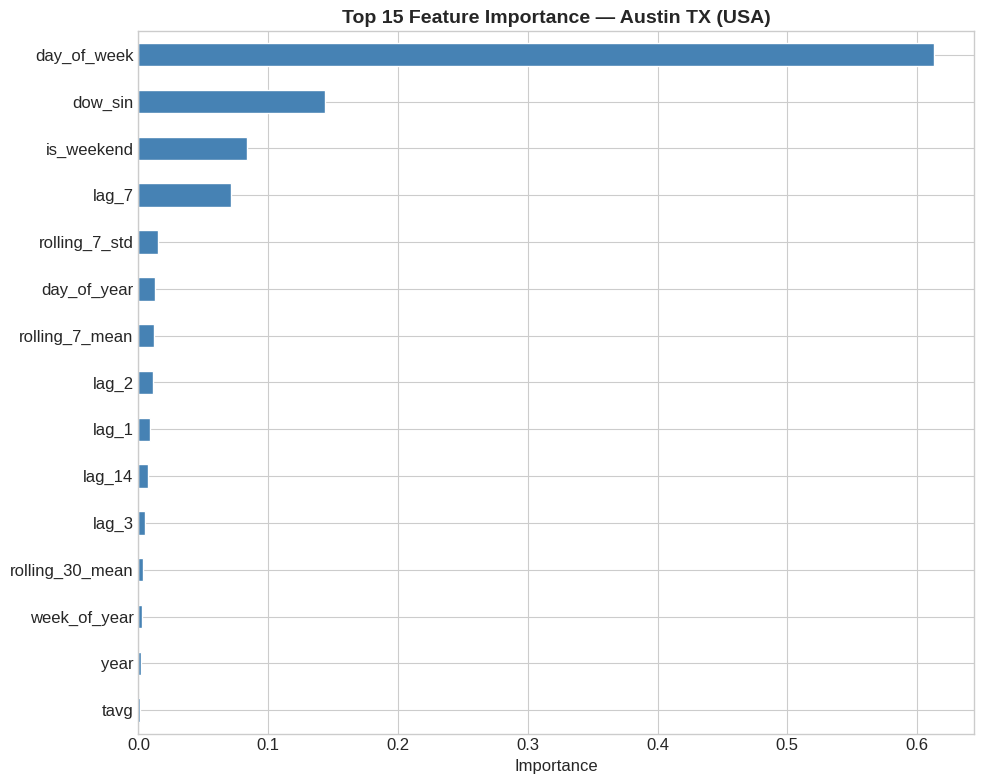


Random Forest PREDICTION — Ballarat (Australia)
Train: 3570 days (2001-02-01 → 2014-09-17)
Test:  90 days (2014-09-18 → 2014-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  10.50 tonnes
RMSE: 18.94 tonnes
MAPE: 17.86%


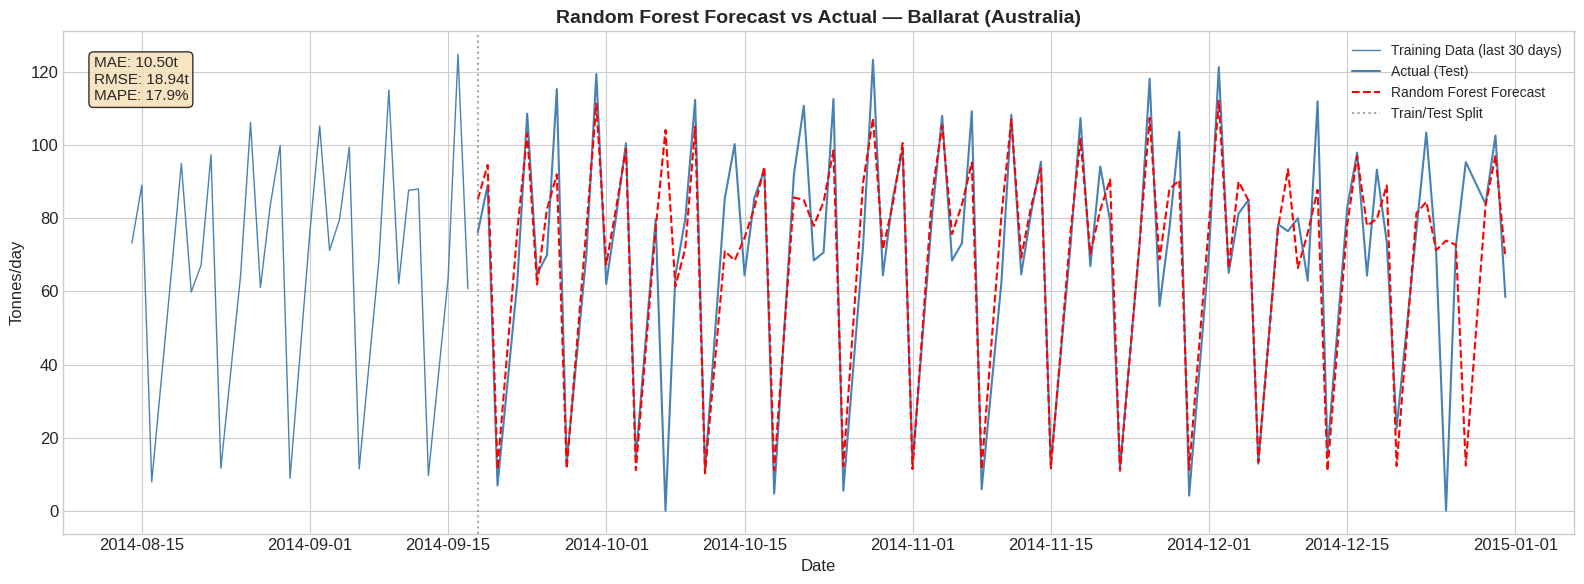

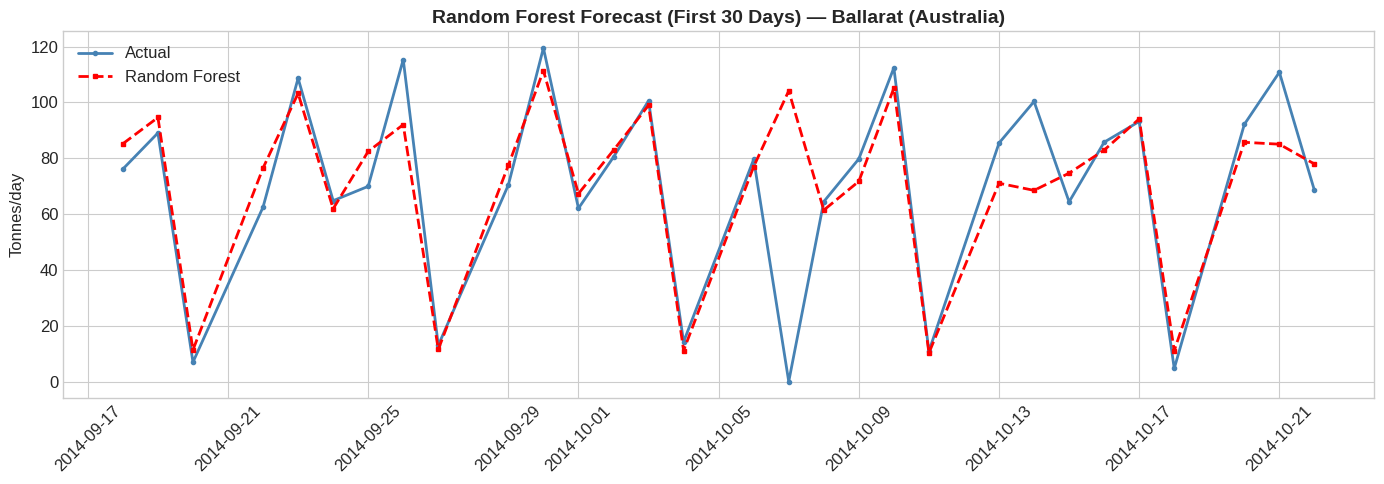

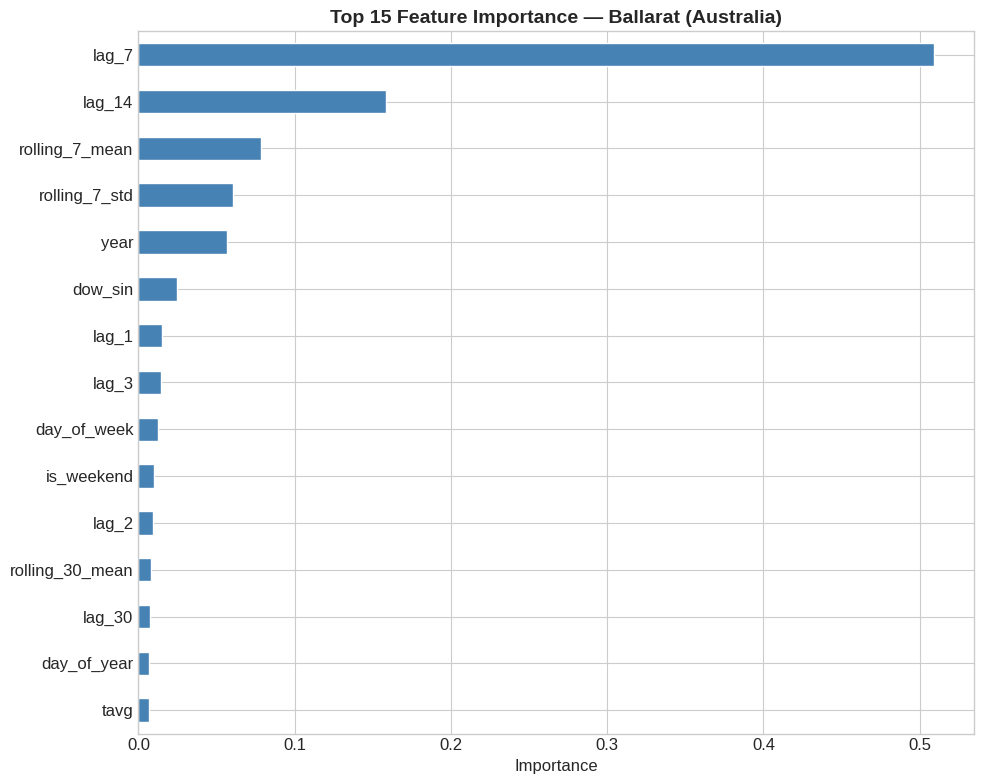

In [7]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_rf_prediction(
            df = df,
            dataset_name = config['label'],
            dataset_code = config['code'],
            dataset_number = config['number'],
            features = FEATURES,
            test_days = 90
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [8]:
print("\n" + "=" * 100)
print("Random Forest RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'MAPE (%)':>9s}")
print("-" * 75)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['mape']:>8.2f}%")

# avg metrics
print("-" * 75)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['mape'].mean():>8.2f}%")

# save results
results_df.to_csv(os.path.join(RES_DIR, 'rf_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/rf_results.csv")


Random Forest RESULTS SUMMARY — ALL DATASETS

Dataset                        |  MAE (t) |  RMSE (t) |  MAPE (%)
---------------------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     6.01 |      8.33 |    41.23%
Dehiwala MC (Sri Lanka)        |    23.50 |     34.46 |    39.05%
Homagama PS (Sri Lanka)        |    10.75 |     13.60 |    36.46%
Moratuwa MC (Sri Lanka)        |    19.69 |     25.72 |    31.61%
Austin TX (USA)                |   155.64 |    343.90 |    35.07%
Ballarat (Australia)           |    10.50 |     18.94 |    17.86%
---------------------------------------------------------------------------
AVERAGE                        |    37.68 |     74.16 |    33.55%

Results saved to: /content/drive/MyDrive/DP/05_prediction_results/rf_results.csv


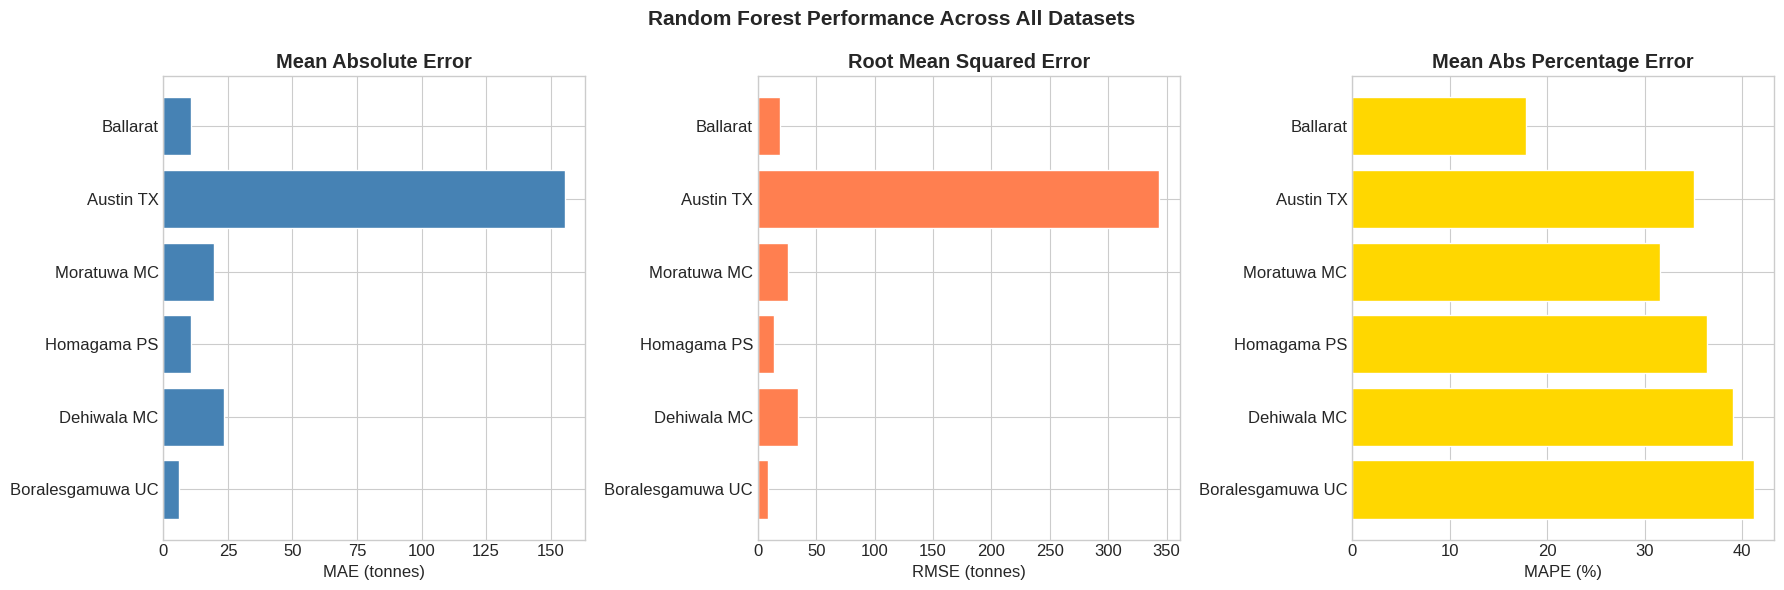

In [9]:
# --- Plot 401: Random Forest Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

# MAE comparison
axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

# RMSE comparison
axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

# MAPE comparison
axes[2].barh(short_names, results_df['mape'], color='gold', edgecolor='white')
axes[2].set_xlabel('MAPE (%)')
axes[2].set_title('Mean Abs Percentage Error', fontweight='bold')

plt.suptitle('Random Forest Performance Across All Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '401_rf_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()